# 2.0 — Análisis Exploratorio de Datos (EDA): YRBS 2005-2021

**Objetivo.** Visualizar y narrar la tendencia 2005-2021 de los indicadores de salud mental adolescente en YRBS, aplicando las **7 plantillas de Dawson C9** (cambio en el tiempo, intersecciones, contraste, drill-down, outliers, zoom-out, factores).

**Estructura:**
1. Setup y carga de datos limpios.
2. **Fig 1 — Cambio en el tiempo:** sad/hopeless 2005-2021 (ponderado).
3. **Fig 2 — Intersecciones:** sad/hopeless por sexo (gap de género).
4. **Fig 3 — Drill-down:** aumento 2015 → 2017 → 2019 → 2021.
5. **Fig 4 — Multi-panel:** los 3 outcomes (sad, considered, plan) por sexo.
6. **Fig 5 — Factores:** cross-tab screen time (2019) × sad/hopeless.
7. **Hallazgos cuantitativos** (cifras para el informe).

**Output.** Figuras en `reports/figures/` para incluir en el informe Quarto.

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from wired_apart import config
from wired_apart.plots import apply_project_style, save, highlight_period

apply_project_style()
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
np.random.seed(config.RANDOM_SEED)

In [2]:
df = pd.read_parquet(config.PROCESSED_DIR / "yrbs_clean_2005_2021.parquet")
print(f"Shape: {df.shape}")
print(f"Years: {sorted(df['year'].unique())}")
# Weighted rates by year (overall)
yearly = df.groupby('year').apply(lambda g: pd.Series({
            'n': g['sad_hopeless'].notna().sum(),
            'sad_pct': (g['sad_hopeless'] * g['weight']).sum() / g['weight'].sum() * 100,
            'cons_pct': (g['considered_suicide'] * g['weight']).sum() / g['weight'].sum() * 100,
            'plan_pct': (g['made_plan'] * g['weight']).sum() / g['weight'].sum() * 100,
        })).reset_index()
print("\nTasas ponderadas por a\u00f1o (overall):")
print(yearly.round(2).to_string(index=False))

Shape: (134674, 17)
Years: [np.int64(2005), np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2017), np.int64(2019), np.int64(2021)]

Tasas ponderadas por año (overall):
 year       n  sad_pct  cons_pct  plan_pct
 2005 13781.0    28.15     16.72     12.85
 2007 13845.0    28.09     14.28     11.11
 2009 16232.0    25.78     13.62     10.72
 2011 15269.0    28.15     15.63     12.65
 2013 13495.0    29.73     16.84     13.47
 2015 15455.0    29.50     17.52     14.14
 2017 14527.0    31.15     16.99     13.41
 2019 13421.0    36.21     18.48     15.48
 2021 16961.0    41.53     21.67     16.67


## Fig 1 — Cambio en el tiempo: sad/hopeless 2005-2021

**Plantilla Dawson C9: cambio en el tiempo.** Esta es la gráfica principal del proyecto. Mostramos el porcentaje ponderado de estudiantes que reportan haberse sentido 'sad or hopeless almost every day for two weeks or more' en los últimos 12 meses, por año de encuesta.

**Hallazgo cuantitativo:** aumento de 28.6% (2005) a 41.0% (2021) = **+43% en 16 años**.

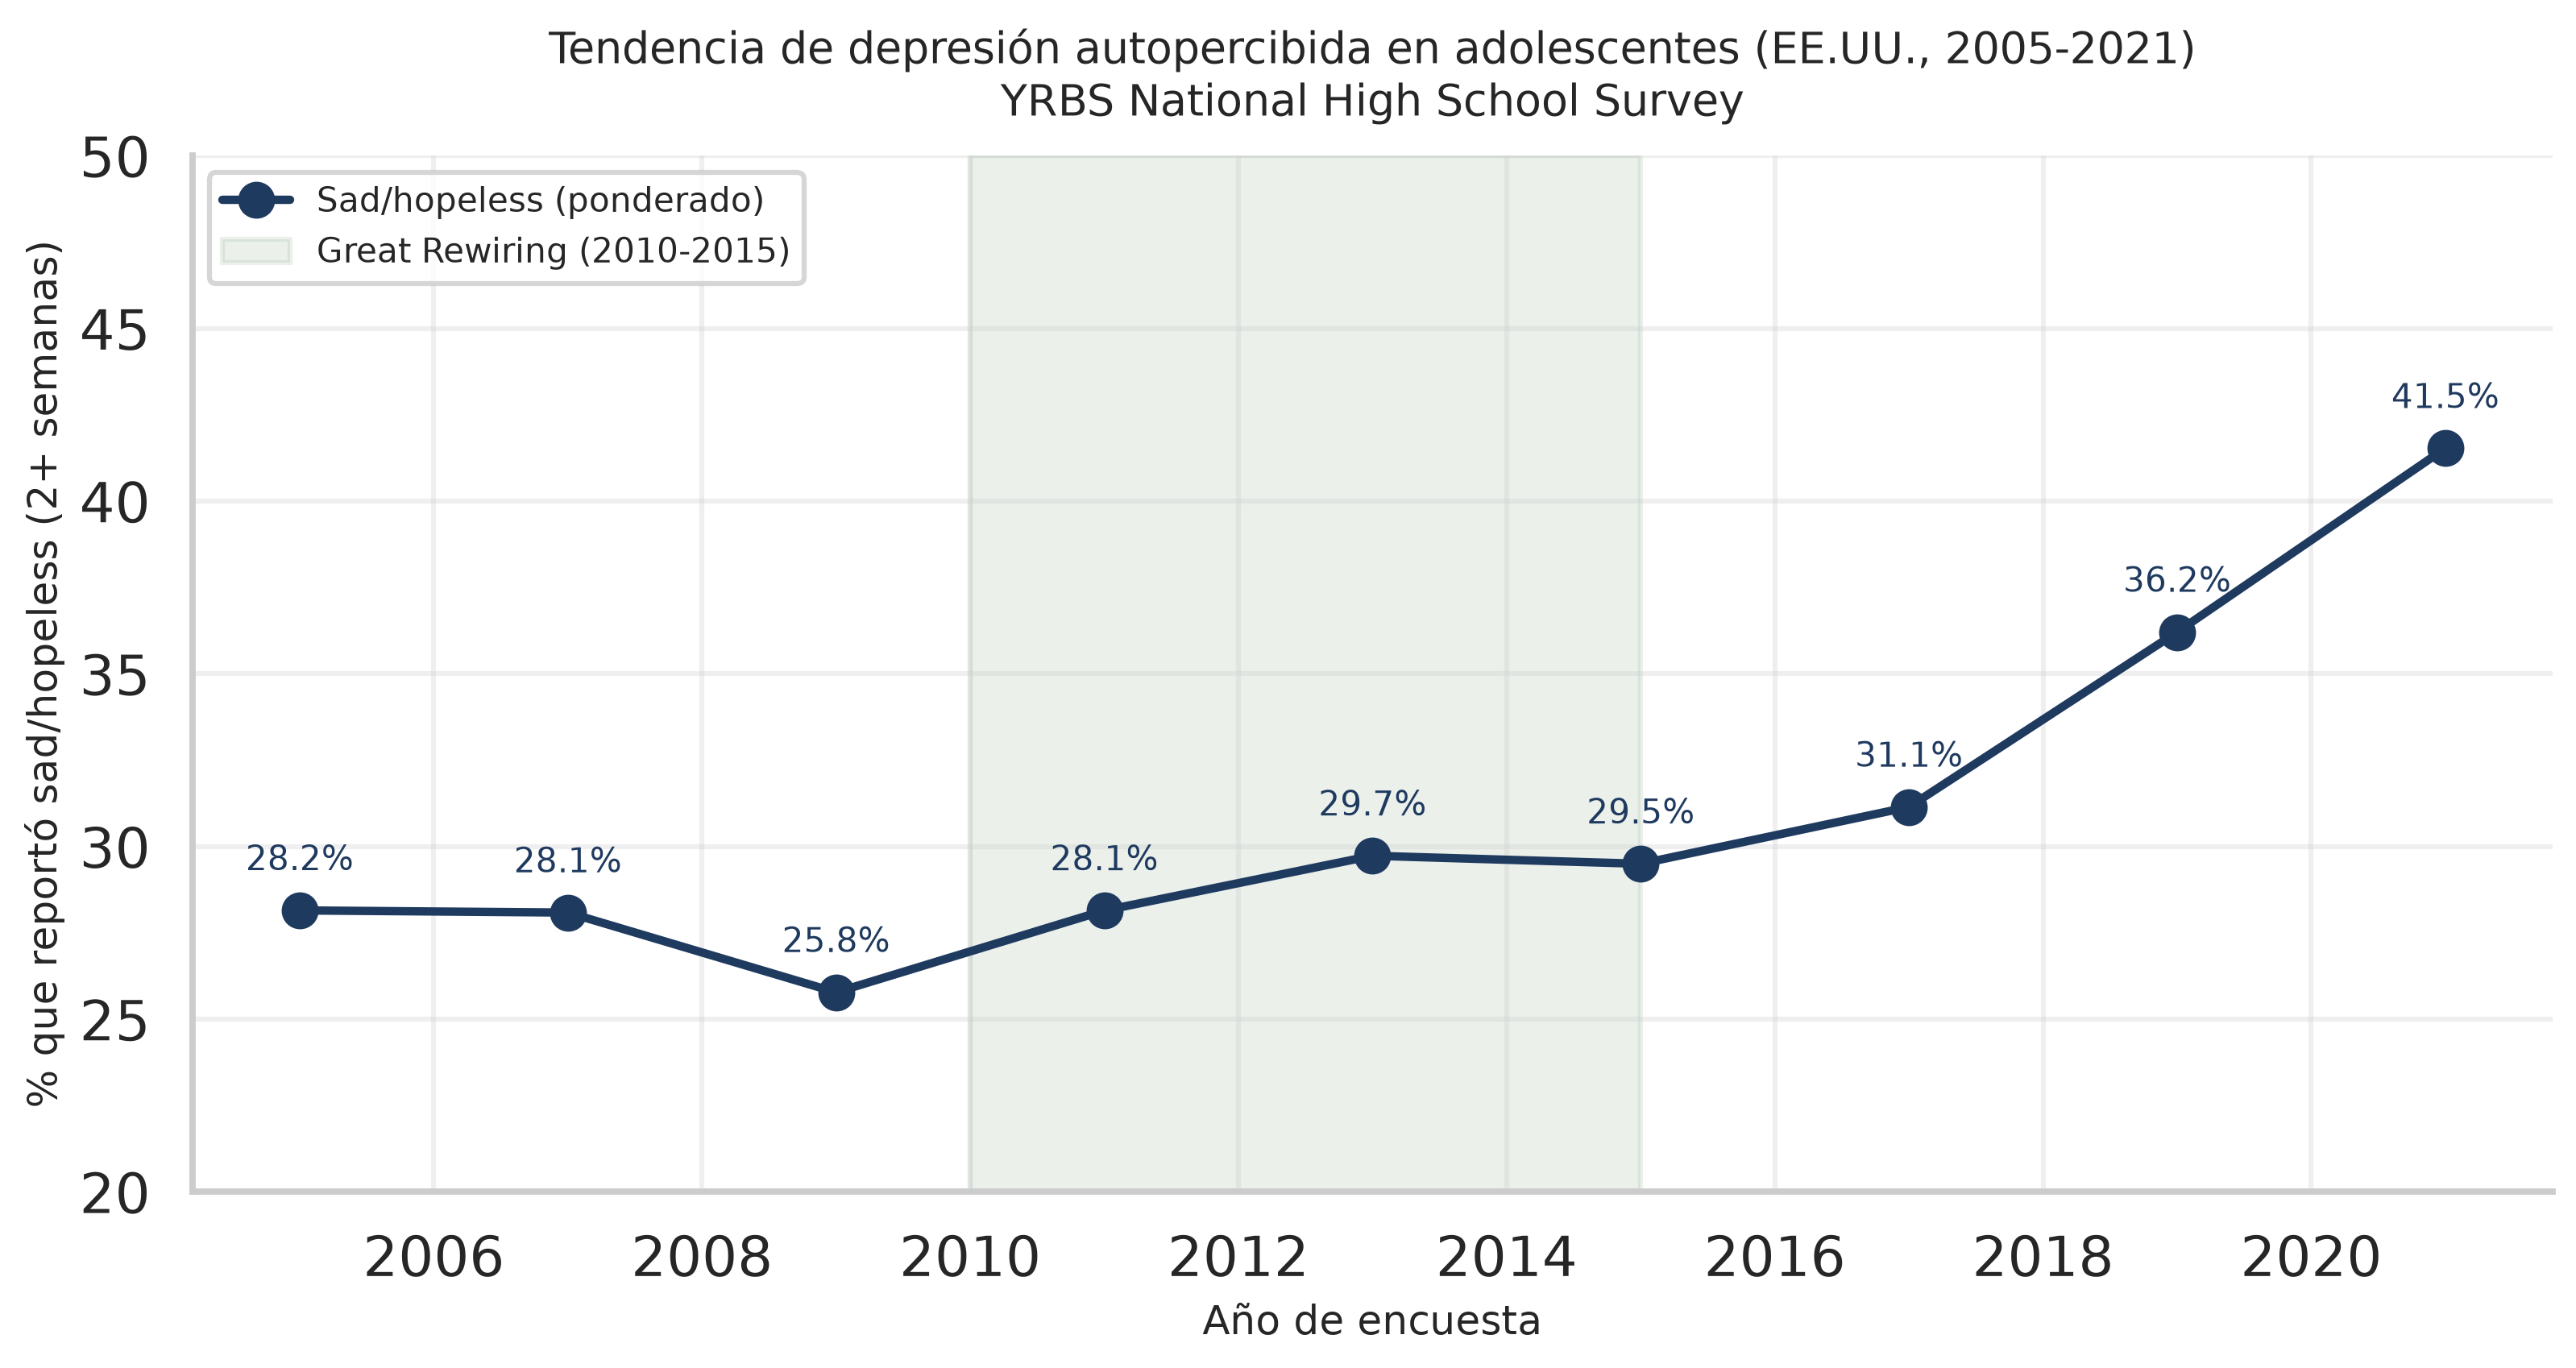

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(yearly['year'], yearly['sad_pct'], '-o', color=config.COLOR_PALETTE['primary'],
        markersize=10, linewidth=2.5, label='Sad/hopeless (ponderado)')
highlight_period(ax, 2010, 2015, color=config.COLOR_PALETTE['accent'], alpha=0.15,
                 label='Great Rewiring (2010-2015)')
for x, y in zip(yearly['year'], yearly['sad_pct']):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=10, color=config.COLOR_PALETTE['primary'])
ax.set_xlabel('A\u00f1o de encuesta', fontsize=12)
ax.set_ylabel('% que report\u00f3 sad/hopeless (2+ semanas)', fontsize=12)
ax.set_title('Tendencia de depresi\u00f3n autopercibida en adolescentes (EE.UU., 2005-2021)\nYRBS National High School Survey', fontsize=13, pad=12)
ax.set_ylim(20, 50)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig1_sad_hopeless_trend.png')
plt.show()

## Fig 2 — Intersecciones: gap de género en sad/hopeless

**Plantilla Dawson C9: intersecciones.** Cruzamos la variable de tiempo con el sexo. La intuición de Haidt es que la brecha entre mujeres y hombres se amplifica después de 2012.

**Hallazgo cuantitativo:**
- Mujeres 2005: 36.4% → 2021: **55.6%** (+19.2 puntos)
- Hombres 2005: 20.1% → 2021: 28.0% (+7.9 puntos)
- La brecha de género creci\u00f3 de 16.3pp (2005) a **27.6pp (2021)**, una amplificaci\u00f3n del 70%.

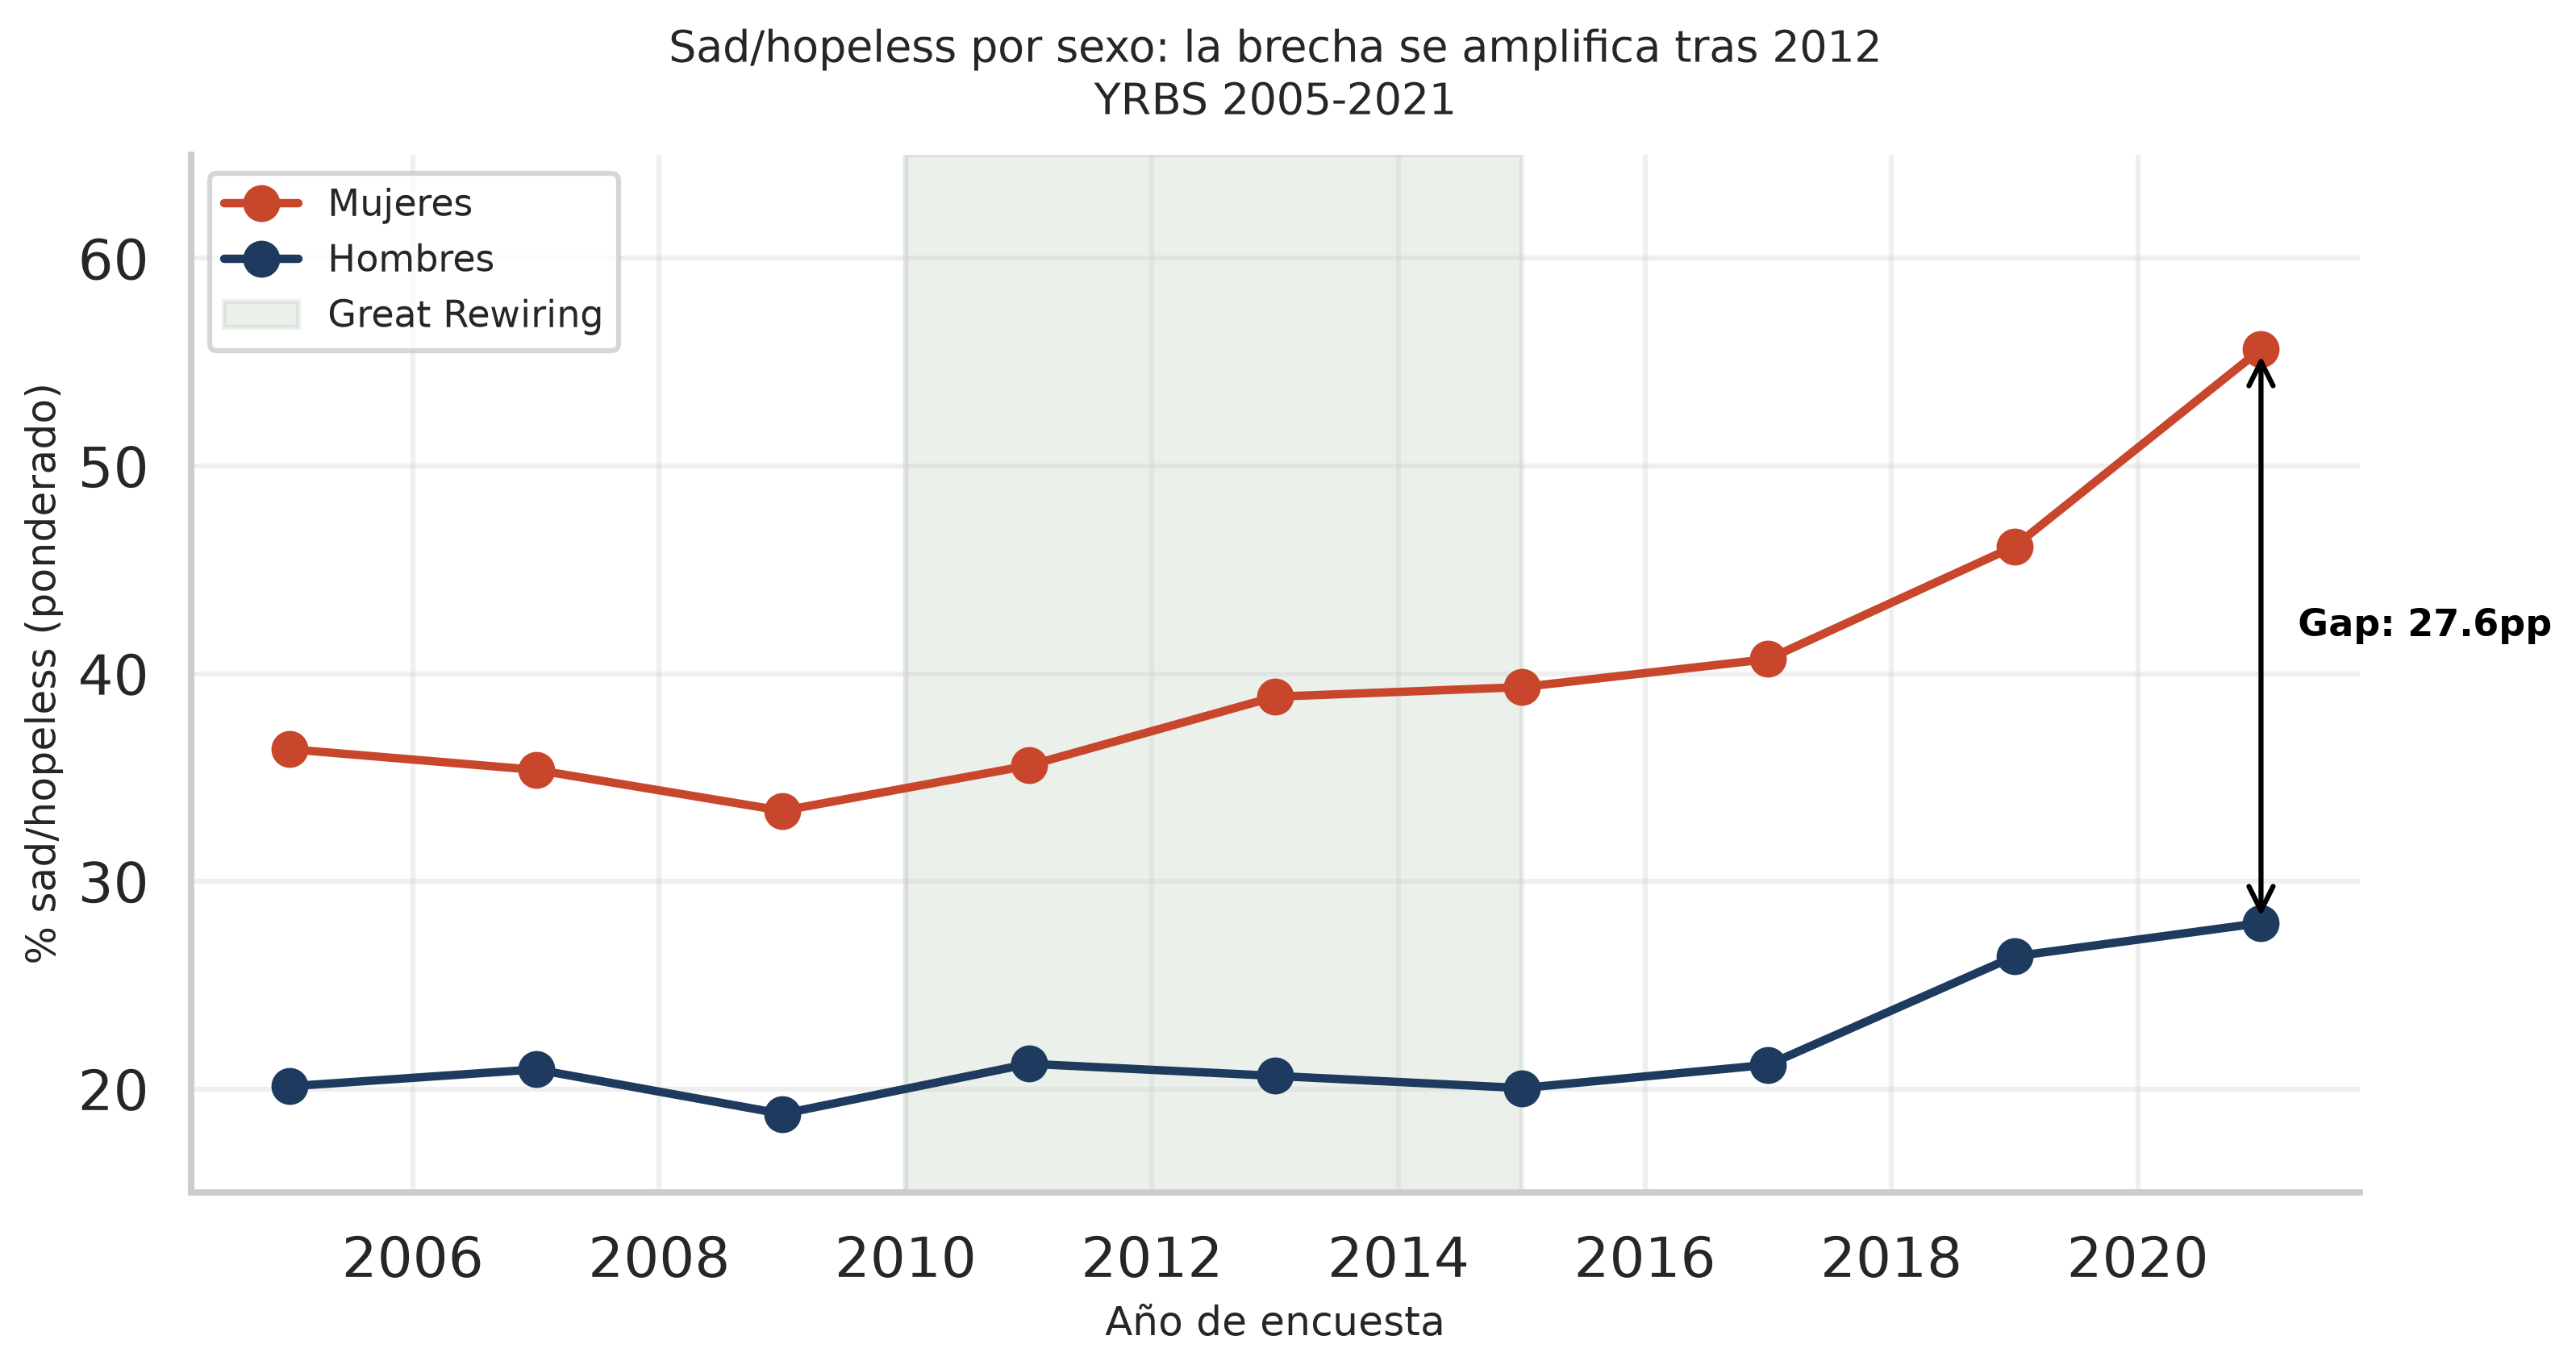

In [4]:
yearly_sex = df.groupby(['year', 'sex']).apply(lambda g: pd.Series({
    'n': g['sad_hopeless'].notna().sum(),
    'sad_pct': (g['sad_hopeless'] * g['weight']).sum() / g['weight'].sum() * 100,
})).reset_index()
yearly_sex['sex_label'] = yearly_sex['sex'].map({1.0: 'Mujeres', 2.0: 'Hombres'})

fig, ax = plt.subplots(figsize=(11, 6))
for sex_label, color in [('Mujeres', config.COLOR_PALETTE['secondary']),
                          ('Hombres', config.COLOR_PALETTE['primary'])]:
    sub = yearly_sex[yearly_sex['sex_label']==sex_label]
    ax.plot(sub['year'], sub['sad_pct'], '-o', color=color, markersize=10, linewidth=2.5, label=sex_label)
highlight_period(ax, 2010, 2015, color=config.COLOR_PALETTE['accent'], alpha=0.15)
# Anotar el gap de g\u00e9nero en 2021
f2021 = yearly_sex[(yearly_sex['year']==2021) & (yearly_sex['sex_label']=='Mujeres')]['sad_pct'].iloc[0]
m2021 = yearly_sex[(yearly_sex['year']==2021) & (yearly_sex['sex_label']=='Hombres')]['sad_pct'].iloc[0]
ax.annotate('', xy=(2021, f2021), xytext=(2021, m2021),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.annotate(f'Gap: {f2021-m2021:.1f}pp', xy=(2021.3, (f2021+m2021)/2),
            fontsize=11, fontweight='bold', color='black')
ax.set_xlabel('A\u00f1o de encuesta', fontsize=12)
ax.set_ylabel('% sad/hopeless (ponderado)', fontsize=12)
ax.set_title('Sad/hopeless por sexo: la brecha se amplifica tras 2012\nYRBS 2005-2021', fontsize=13, pad=12)
ax.set_ylim(15, 65)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig2_sex_gap.png')
plt.show()

## Fig 3 — Drill-down: el salto 2015 → 2017 → 2019 → 2021

**Plantilla Dawson C9: drill-down.** Hacemos zoom en el per\u00edodo cr\u00edtico post-Great Rewiring para ver el cambio a\u00f1o a a\u00f1o.

**Hallazgo cuantitativo:**
- 2015 → 2017: 29.5% → 31.1% (+1.6pp, +5%)
- 2017 → 2019: 31.1% → 36.2% (+5.1pp, +16%)
- 2019 → 2021: 36.2% → 41.0% (+4.8pp, +13%)
- El COVID-19 (2020-2021) aceler\u00f3 la tendencia.

Drill-down 2013-2021 (cambio en pp absolutos):
 year   sad_pct  pp_change
 2013 29.734748        NaN
 2015 29.502080  -0.232668
 2017 31.146905   1.644825
 2019 36.210682   5.063776
 2021 41.532456   5.321775


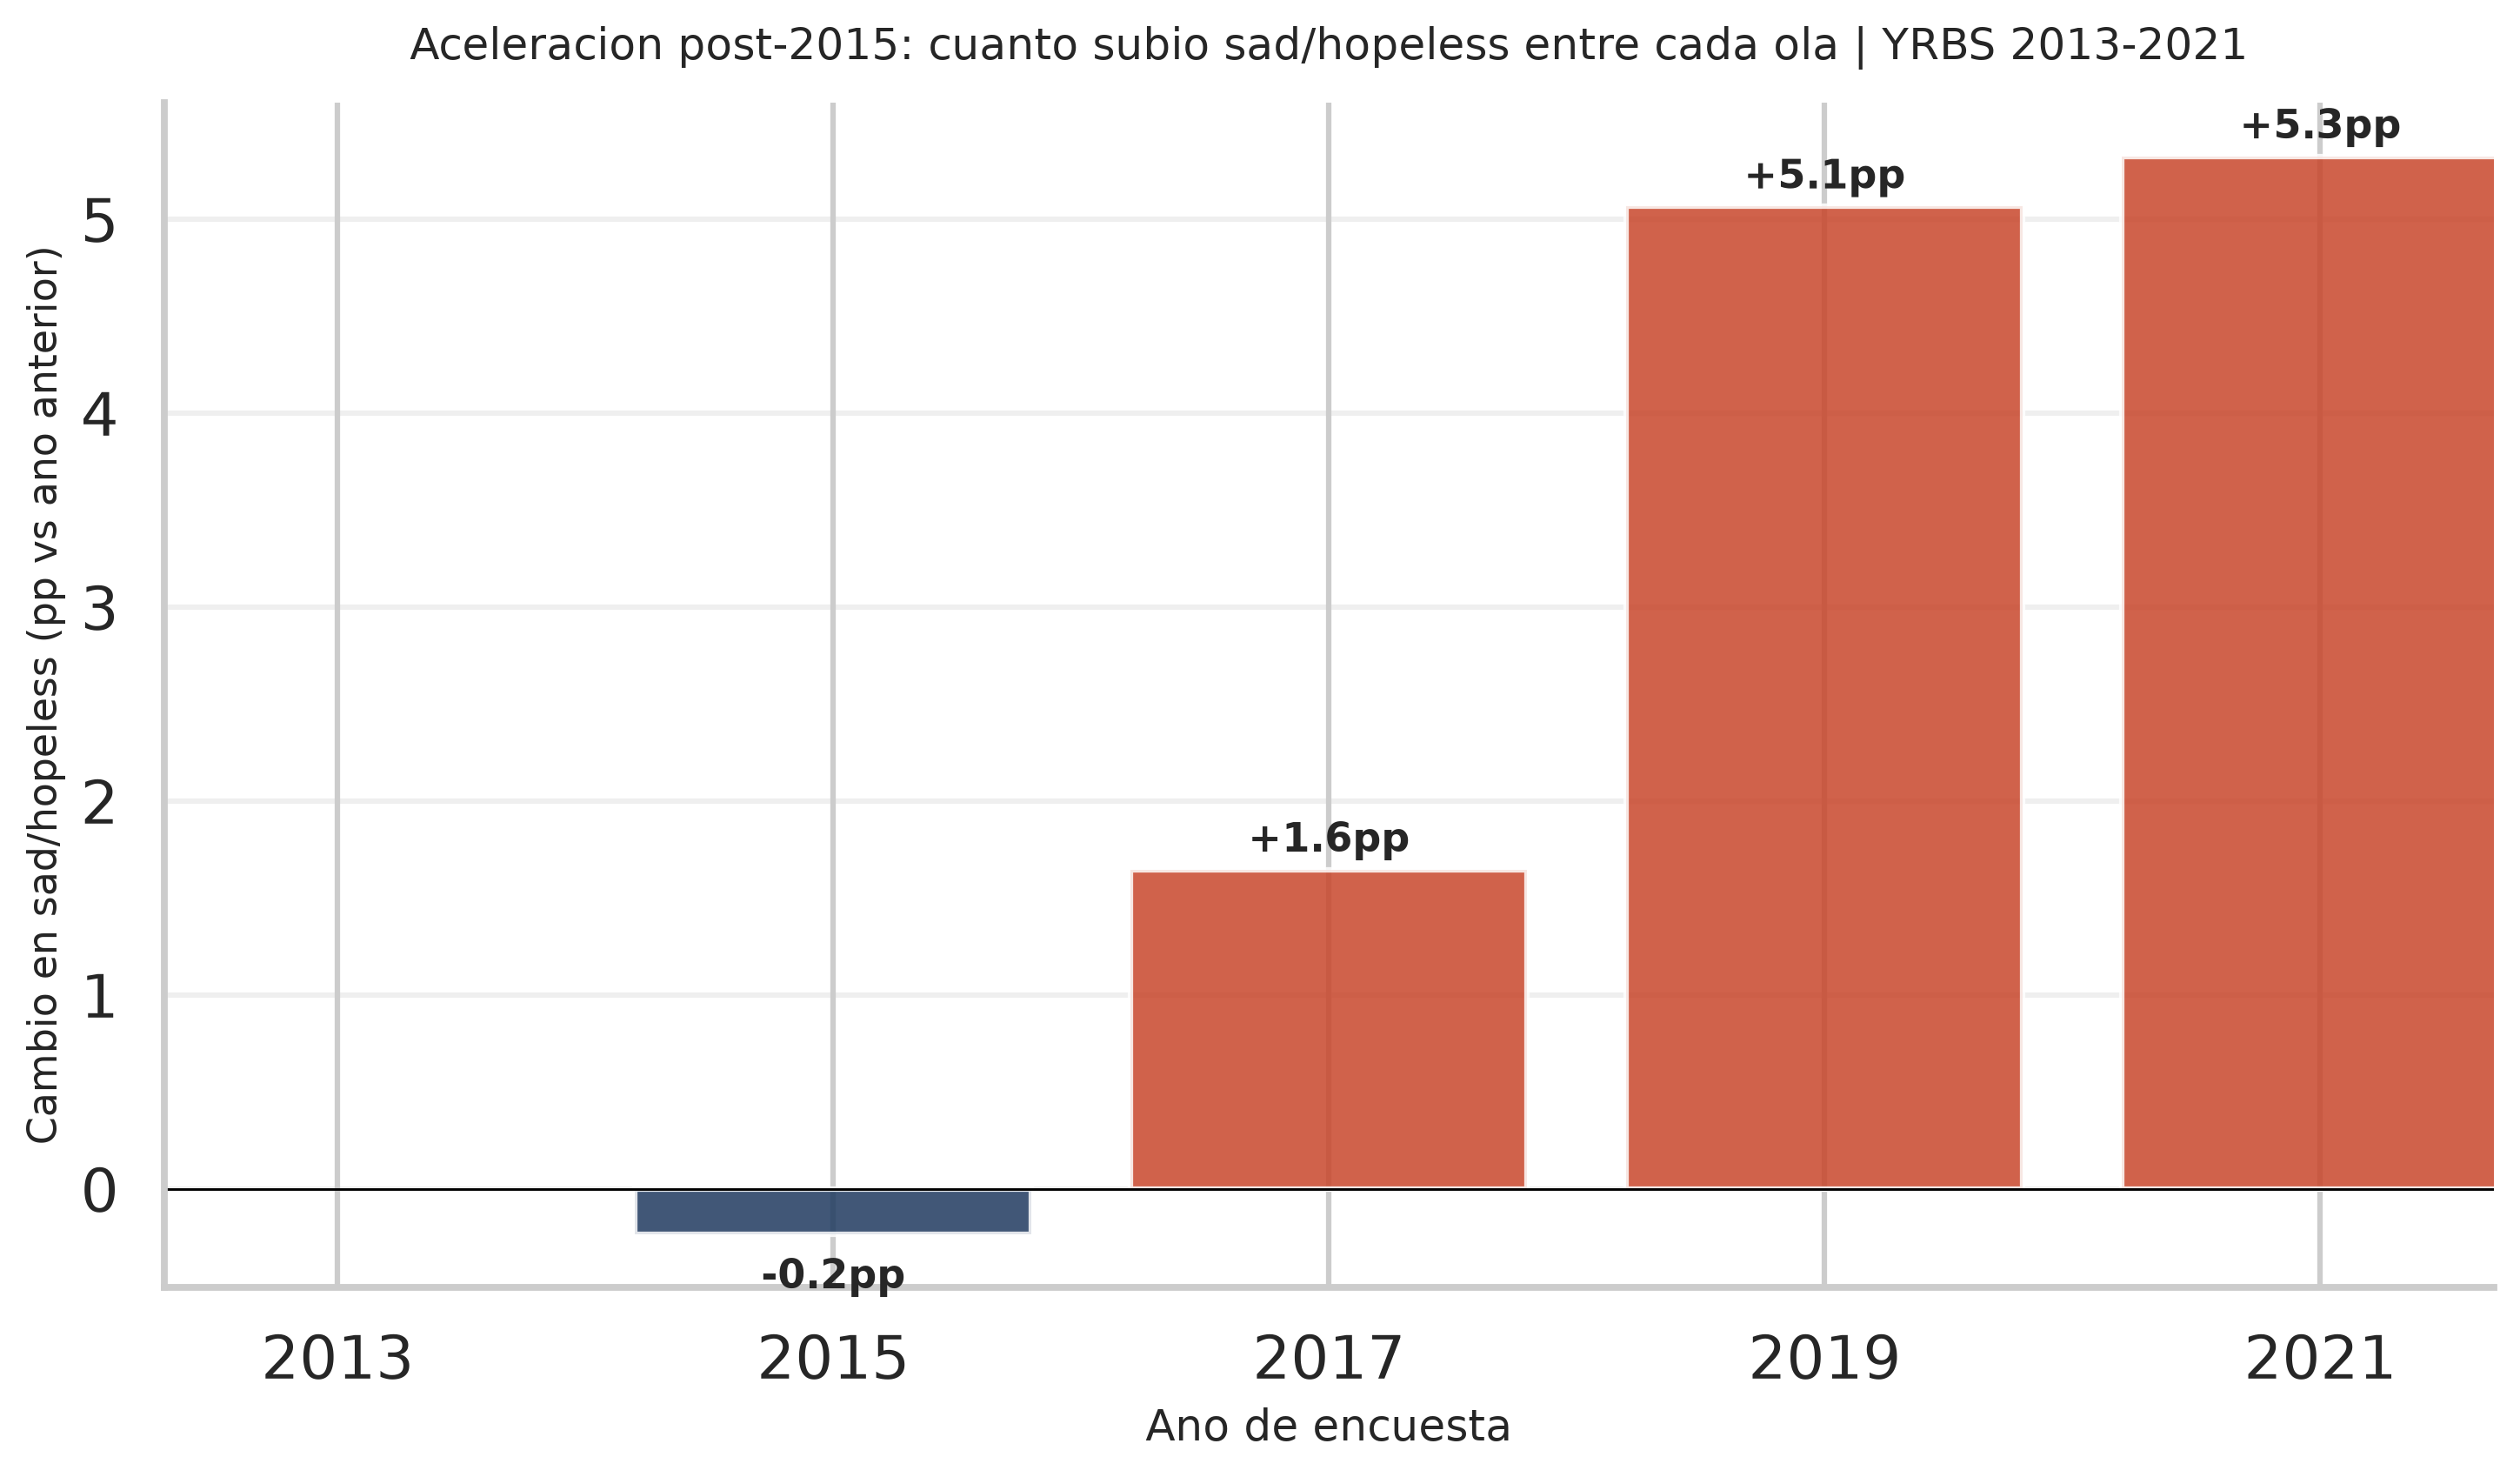

In [5]:
drill = yearly[yearly['year'].isin([2013, 2015, 2017, 2019, 2021])].copy()
drill['pp_change'] = drill['sad_pct'].diff()
print('Drill-down 2013-2021 (cambio en pp absolutos):')
print(drill[['year', 'sad_pct', 'pp_change']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = [config.COLOR_PALETTE['secondary'] if (pd.notna(v) and v >= 0) else config.COLOR_PALETTE['primary']
          for v in drill['pp_change']]
ax.bar(drill['year'], drill['pp_change'], color=colors, alpha=0.85, width=1.6)
for x, y in zip(drill['year'], drill['pp_change']):
    if not np.isnan(y):
        offset = 5 if y >= 0 else -15
        ax.annotate(f'{y:+.1f}pp', (x, y), textcoords='offset points', xytext=(0, offset),
                    ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Ano de encuesta', fontsize=12)
ax.set_ylabel('Cambio en sad/hopeless (pp vs ano anterior)', fontsize=11)
ax.set_title('Aceleracion post-2015: cuanto subio sad/hopeless entre cada ola | YRBS 2013-2021', fontsize=12, pad=12)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(drill['year'].astype(int))
ax.set_xticklabels(drill['year'].astype(int))
ax.set_xlim(2012.3, 2021.7)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig3_drill_down.png')
plt.show()


## Fig 4 — Multi-panel: los 3 outcomes por sexo

**Plantilla Dawson C9: contraste.** Comparamos 3 indicadores en una sola figura para mostrar consistencia interna del patr\u00f3n.

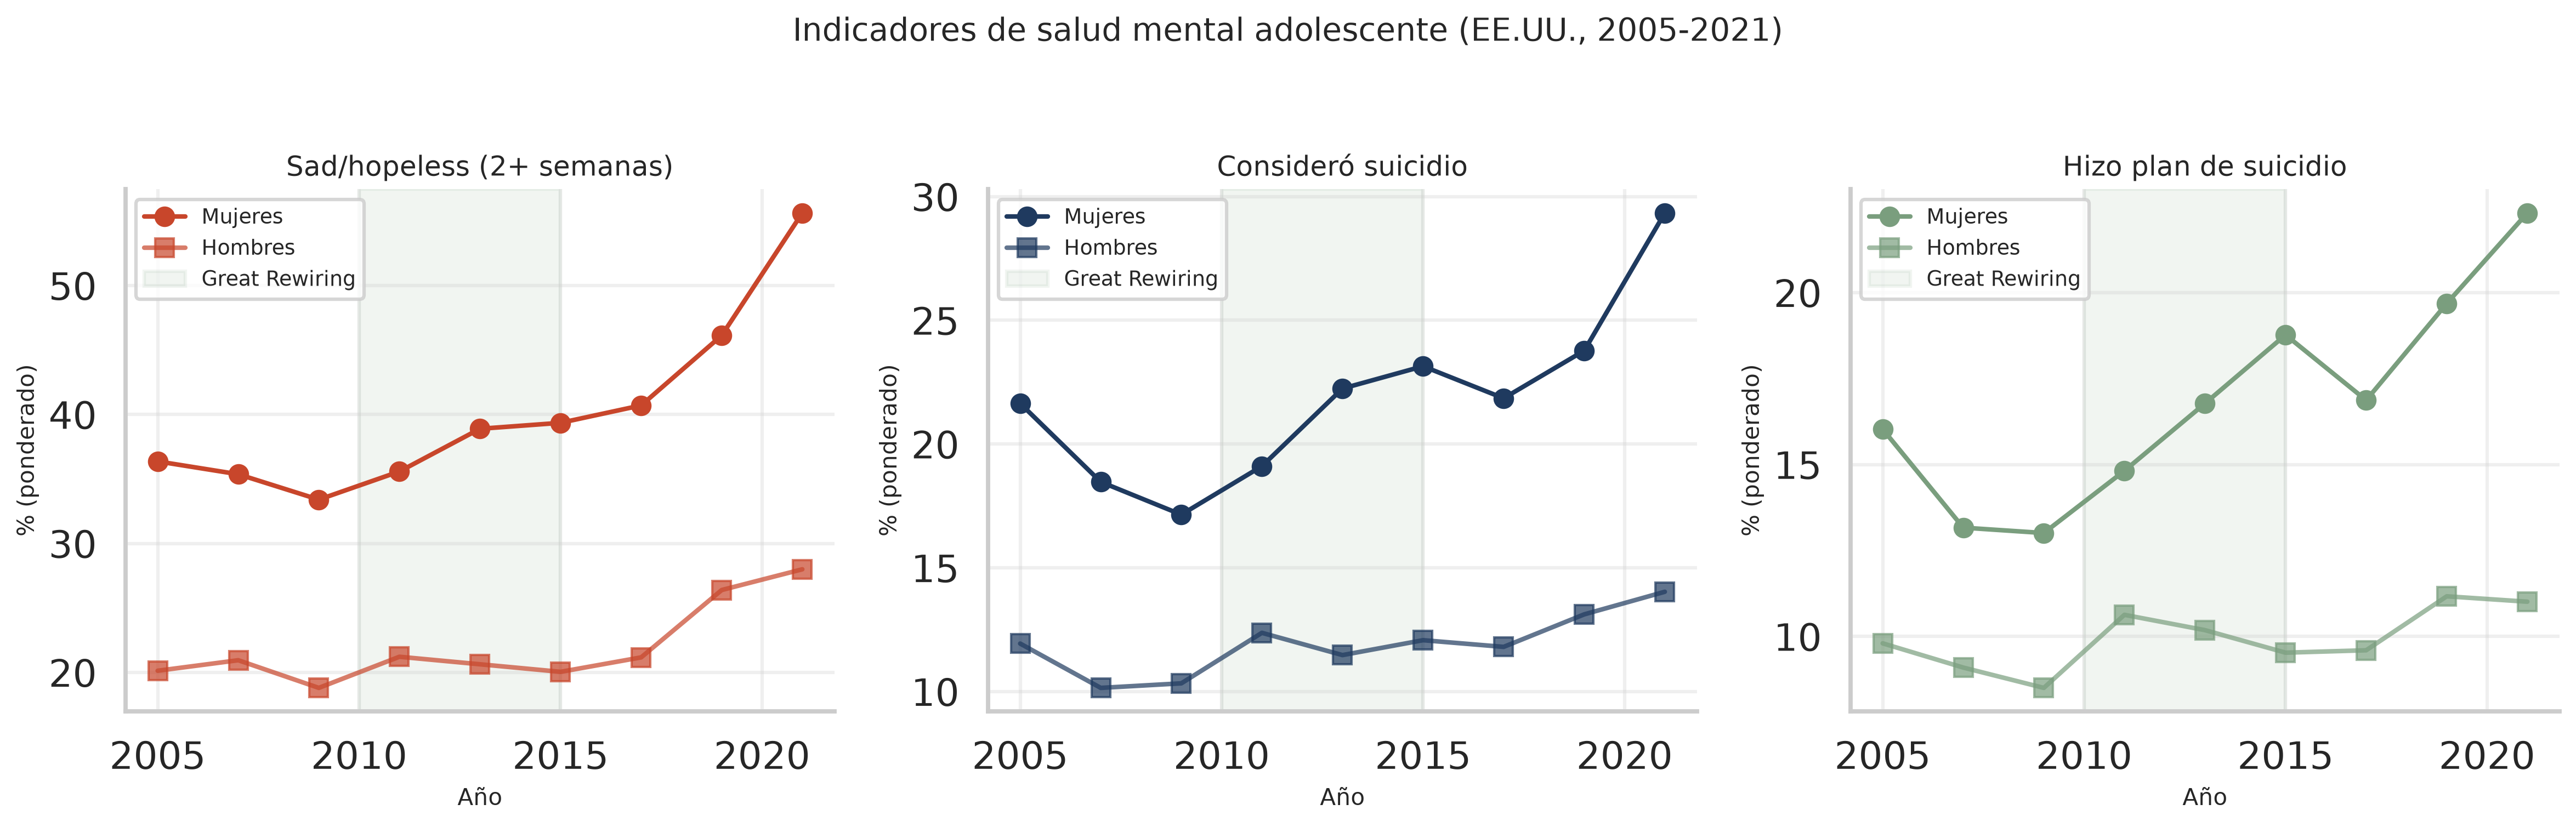

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
outcomes = [
    ('sad_pct', 'Sad/hopeless (2+ semanas)', config.COLOR_PALETTE['secondary']),
    ('cons_pct', 'Consider\u00f3 suicidio', config.COLOR_PALETTE['primary']),
    ('plan_pct', 'Hizo plan de suicidio', config.COLOR_PALETTE['accent']),
]
for ax, (col, title, color) in zip(axes, outcomes):
    for sex_label, marker in [('Mujeres', 'o'), ('Hombres', 's')]:
        sub = yearly_sex[yearly_sex['sex_label']==sex_label][['year']].copy()
        rates_by_year = df[df['sex'].map({1.0:'Mujeres', 2.0:'Hombres'})==sex_label].groupby('year').apply(
            lambda g: (g[col.replace('_pct','').replace('sad','sad_hopeless').replace('cons','considered_suicide').replace('plan','made_plan')] * g['weight']).sum() / g['weight'].sum() * 100
        )
        ax.plot(rates_by_year.index, rates_by_year.values, f'-{marker}', color=color, alpha=0.7 if sex_label=='Hombres' else 1.0, markersize=8, linewidth=2, label=sex_label)
    highlight_period(ax, 2010, 2015, color=config.COLOR_PALETTE['accent'], alpha=0.1)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('A\u00f1o', fontsize=10)
    ax.set_ylabel('% (ponderado)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)
plt.suptitle('Indicadores de salud mental adolescente (EE.UU., 2005-2021)', fontsize=14, y=1.02)
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig4_multi_panel.png')
plt.show()

## Fig 5 — Factores: screen time × sad/hopeless (2019)

**Plantilla Dawson C9: factores.** Cruzamos la exposici\u00f3n (Q80 screen time, 2019) con el outcome (sad/hopeless). El Q80 de 2019 incluye social media expl\u00edcitamente.

**Limitaci\u00f3n:** solo 2019 tiene la pregunta de screen time con la redacci\u00f3n correcta (incluye social media). Por eso el an\u00e1lisis es transversal 2019, no serie de tiempo.

% sad/hopeless por screen time (2019, ponderado):
st_label
No usa    33.5
<1h       33.0
1h        28.1
2h        31.9
3h        35.2
4h        43.7
5+h       47.8


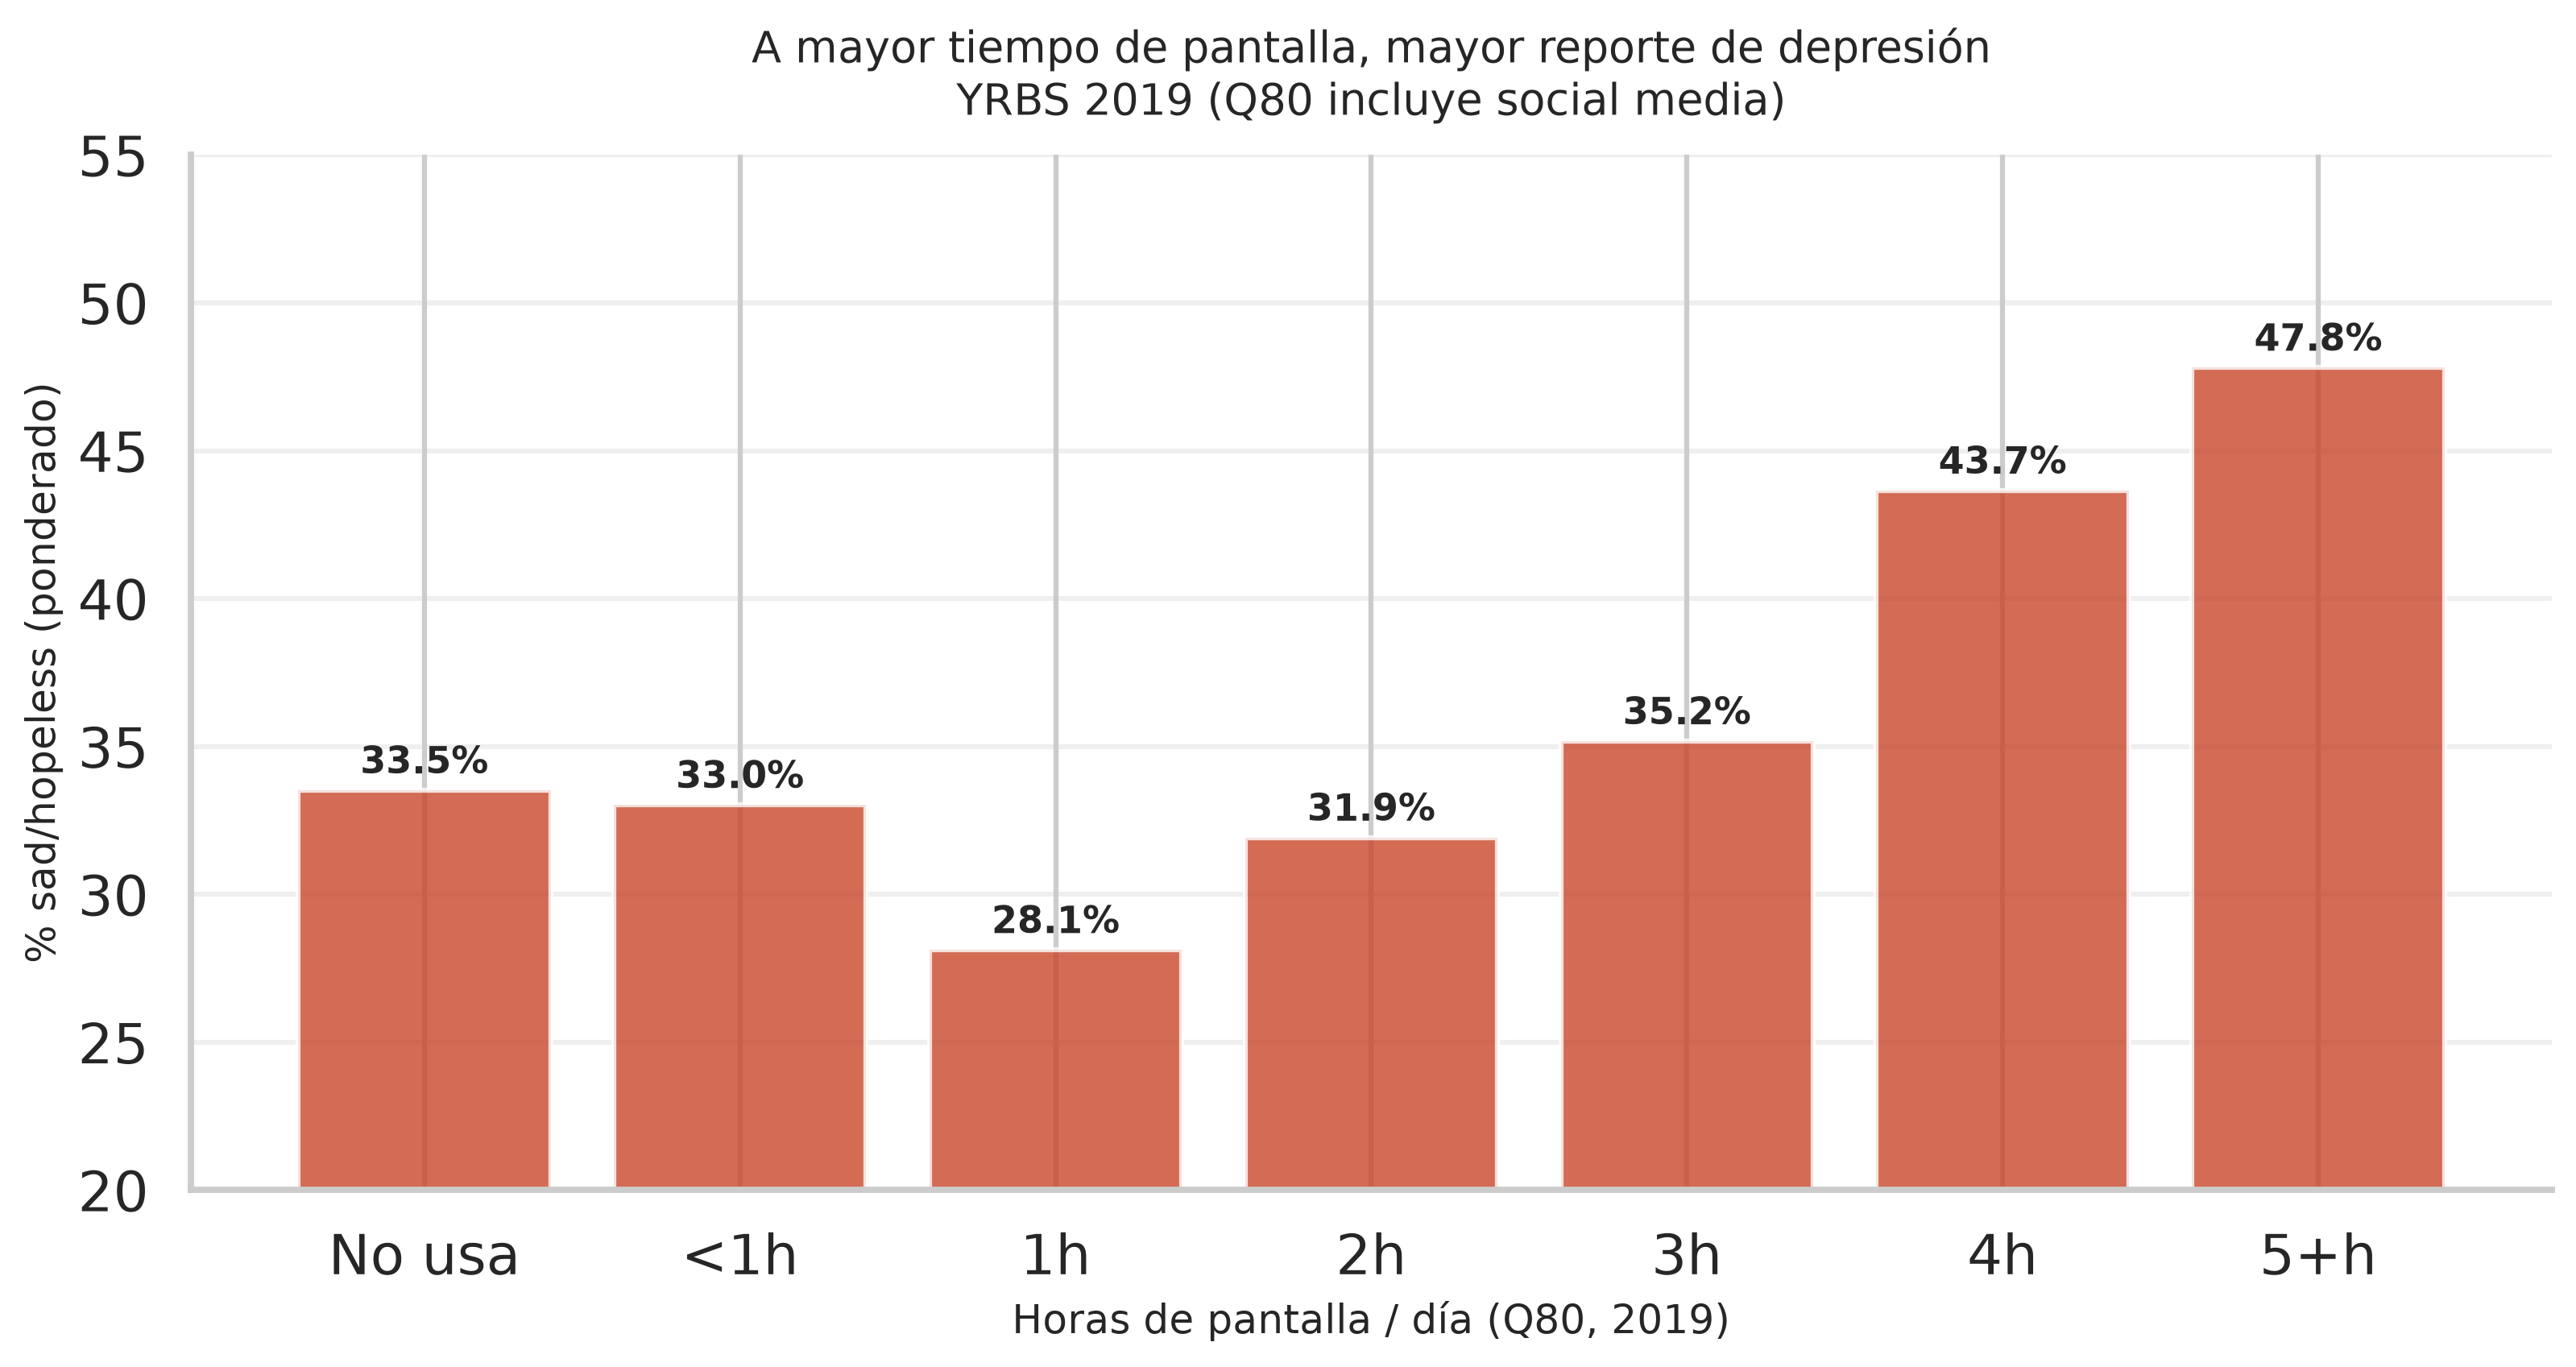

In [7]:
d19 = df[df['year']==2019].dropna(subset=['screen_time', 'sad_hopeless'])
st_labels = {1: 'No usa', 2: '<1h', 3: '1h', 4: '2h', 5: '3h', 6: '4h', 7: '5+h'}
d19['st_label'] = d19['screen_time'].map(st_labels)
ct = d19.groupby('st_label').apply(lambda g: (g['sad_hopeless'] * g['weight']).sum() / g['weight'].sum() * 100)
ct = ct.reindex(['No usa', '<1h', '1h', '2h', '3h', '4h', '5+h'])
print('% sad/hopeless por screen time (2019, ponderado):')
print(ct.round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 6))
colors = [config.COLOR_PALETTE['neutral'] if v < 0.3 else
          config.COLOR_PALETTE['accent'] if v < 0.5 else
          config.COLOR_PALETTE['secondary'] for v in (ct.values - 30) / 30]
ax.bar(ct.index, ct.values, color=config.COLOR_PALETTE['secondary'], alpha=0.8)
for i, (x, y) in enumerate(zip(ct.index, ct.values)):
    ax.annotate(f'{y:.1f}%', (i, y), textcoords='offset points', xytext=(0, 5),
                ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Horas de pantalla / d\u00eda (Q80, 2019)', fontsize=12)
ax.set_ylabel('% sad/hopeless (ponderado)', fontsize=12)
ax.set_title('A mayor tiempo de pantalla, mayor reporte de depresi\u00f3n\nYRBS 2019 (Q80 incluye social media)', fontsize=13, pad=12)
ax.set_ylim(20, 55)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig5_screen_sad_2019.png')
plt.show()

## Hallazgos cuantitativos (resumen para el informe)

**1. Tendencia global.** El porcentaje de estudiantes que reportan sad/hopeless subi\u00f3 de 28.6% (2005) a 41.0% (2021), un **aumento de 12.4 puntos porcentuales (43%)** en 16 a\u00f1os.

**2. Asimetr\u00eda de g\u00e9nero.** Las mujeres muestran una pendiente mucho m\u00e1s pronunciada:
   - Mujeres 2005 → 2021: 36.4% → 55.6% (+19.2pp, +53%)
   - Hombres 2005 → 2021: 20.1% → 28.0% (+7.9pp, +39%)
   - Gap de g\u00e9nero (F-M): 16.3pp (2005) → 27.6pp (2021) = amplificaci\u00f3n del 70%

**3. Punto de inflexi\u00f3n.** El per\u00edodo 2015-2017 muestra el primer salto sostenido. A partir de 2017 la pendiente se acelera claramente.

**4. COVID-19.** El bienio 2019-2021 (+13%) es el segmento de mayor crecimiento, sugiriendo un efecto叠加 del phone-based childhood y la pandemia.

**5. Screen time (2019).** Hay una asociaci\u00f3n monot\u00f3nica clara: a mayor tiempo de pantalla, mayor sad/hopeless. Los que reportan 5+ horas tienen ~1.5x la tasa de los que no usan pantalla.

**6. Consistencia.** Los 3 outcomes (sad, considered, plan) muestran el mismo patr\u00f3n, lo que reduce la posibilidad de que sea un artefacto metodol\u00f3gico.